In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
with open("../models/preprocessing_params.pkl", "rb") as f:
    preprocessing_params = pickle.load(f)

with open("../models/logit_model.pkl", "rb") as f:
    logit_model = pickle.load(f)

In [3]:
def preprocess_data(input_df, preprocessing_params):

    output_df = input_df.copy()

    # Missing-value imputation
    output_df["monthly_income_imp"] = output_df["monthly_income"].fillna(
        preprocessing_params["imputation_values"]["monthly_income"]
    )

    # Special-value replacement
    output_df["age_imp"] = output_df["age"].replace(
        preprocessing_params["special_value_replacements"]["age"]
    )

    output_df["n_dpd_90plus_hist_imp"] = output_df["n_dpd_90plus_hist"].replace(
        preprocessing_params["special_value_replacements"]["n_dpd_90plus_hist"]
    )

    output_df["n_dpd_30_50_l2yrs_imp"] = output_df["n_dpd_30_50_l2yrs"].replace(
        preprocessing_params["special_value_replacements"]["n_dpd_30_50_l2yrs"]
    )

    return output_df

In [4]:
def woe_transformation_n_dpd_90plus_hist_imp(value):

    if value < 0.50:
        return 0.368445
    else:
        return -2.280864

def woe_transformation_n_dpd_30_50_l2yrs_imp(value):

    if value < 0.50:
        return 0.513985

    elif value < 1.50:
        return -0.903654

    else:
        return -1.865336

def woe_transformation_avg_util_unsec(value):

    if value < 0.06:
        return 1.395448

    elif value < 0.13:
        return 1.196037

    elif value < 0.22:
        return 0.801477

    elif value < 0.30:
        return 0.571255

    elif value < 0.39:
        return 0.264197

    elif value < 0.49:
        return 0.042306

    elif value < 0.70:
        return -0.380305

    elif value < 0.90:
        return -0.889439

    else:
        return -1.396248

def woe_transformation_age_imp(value):

    if value < 29.50:
        return -0.618478

    elif value < 36.50:
        return -0.502841

    elif value < 43.50:
        return -0.326797

    elif value < 47.50:
        return -0.210692

    elif value < 49.50:
        return -0.171605

    elif value < 52.50:
        return -0.130183

    elif value < 55.50:
        return -0.026589

    elif value < 59.50:
        return 0.253172

    elif value < 62.50:
        return 0.369651

    elif value < 67.50:
        return 0.726566

    elif value < 74.50:
        return 1.040110

    else:
        return 1.248390

def woe_transformation_monthly_income_imp(value):

    if value < 1508.50:
        return -0.099183

    elif value < 2569.50:
        return -0.394654

    elif value < 3331.50:
        return -0.469783

    elif value < 4833.50:
        return -0.229363

    elif value < 5333.50:
        return -0.062597

    elif value < 6643.50:
        return 0.117460

    elif value < 7656.50:
        return 0.197259

    elif value < 9945.50:
        return 0.281425

    else:
        return 0.460761

def woe_transformation_debt_income_ratio(value):

    if value < 0.02:
        return 0.297162

    elif value < 0.35:
        return 0.118882

    elif value < 0.42:
        return 0.057786

    elif value < 0.51:
        return -0.088438

    elif value < 0.65:
        return -0.321729

    elif value < 3.97:
        return -0.596973

    elif value < 995.50:
        return 0.063366

    else:
        return 0.328563


def apply_woe_transformation(input_df):

    output_df = input_df.copy()

    output_df["n_dpd_90plus_hist_imp_woe"] = output_df["n_dpd_90plus_hist_imp"].apply(woe_transformation_n_dpd_90plus_hist_imp)
    output_df["n_dpd_30_50_l2yrs_imp_woe"] = output_df["n_dpd_30_50_l2yrs_imp"].apply(woe_transformation_n_dpd_30_50_l2yrs_imp)
    output_df["avg_util_unsec_woe"] = output_df["avg_util_unsec"].apply(woe_transformation_avg_util_unsec)
    output_df["age_imp_woe"] = output_df["age_imp"].apply(woe_transformation_age_imp)
    output_df["monthly_income_imp_woe"] = output_df["monthly_income_imp"].apply(woe_transformation_monthly_income_imp)
    output_df["debt_income_ratio_woe"] = output_df["debt_income_ratio"].apply(woe_transformation_debt_income_ratio)

    return output_df

In [5]:
input_df = pd.DataFrame({
    "avg_util_unsec": [0.78],
    "n_dpd_90plus_hist": [0],
    "n_dpd_30_50_l2yrs": [98],
    "age": [61],
    "monthly_income": [5001.0],
    "debt_income_ratio": [0.81]
})

display(input_df)

,avg_util_unsec,n_dpd_90plus_hist,n_dpd_30_50_l2yrs,age,monthly_income,debt_income_ratio
0,0.78,0,98,61,5001.0,0.81


In [6]:
preprocessed_df = preprocess_data(input_df, preprocessing_params)
woe_transformed_df = apply_woe_transformation(preprocessed_df)

woe_transformed_df = sm.add_constant(
    woe_transformed_df, 
    has_constant="add"
)

model_variables = logit_model.params.index.tolist()

In [7]:
X = woe_transformed_df[model_variables]
predicted_probability = logit_model.predict(X)

In [55]:
coefficients = logit_model.params.drop("const")
contributions = coefficients * woe_transformed_df[coefficients.index].iloc[0]
contributions

n_dpd_90plus_hist_imp_woe   -0.225688
n_dpd_30_50_l2yrs_imp_woe   -0.321033
avg_util_unsec_woe           0.604545
age_imp_woe                 -0.174681
monthly_income_imp_woe       0.013449
debt_income_ratio_woe        0.397106
dtype: float64

In [56]:
contributions = contributions.reset_index()
contributions["abs_contri"] = contributions[0].abs()

In [57]:
var_contri_table = (
    pd.DataFrame(contributions)
    .rename(columns={'index': "var", 0: "contri"})
    .sort_values(
        by="abs_contri",
        ascending=False
    )
)

display(var_contri_table)

,var,contri,abs_contri
2,avg_util_unsec_woe,0.604545,0.604545
5,debt_income_ratio_woe,0.397106,0.397106
1,n_dpd_30_50_l2yrs_imp_woe,-0.321033,0.321033
0,n_dpd_90plus_hist_imp_woe,-0.225688,0.225688
3,age_imp_woe,-0.174681,0.174681
4,monthly_income_imp_woe,0.013449,0.013449


In [58]:
vars_desc_mapper = {
    "avg_util_unsec_woe" : "Average Utilization of Unsecured Lines of Credit",
    "debt_income_ratio_woe" : "Debt-to-Income Ratio",
    "n_dpd_30_50_l2yrs_imp_woe" : "Number of Days Past Due (30-50) in Last 2 Years",
    "n_dpd_90plus_hist_imp_woe" : "Number of Days Past Due (90+) in History",
    "age_imp_woe" : "Age",
    "monthly_income_imp_woe" : "Monthly Income"
}

In [59]:
var_contri_table["variable_desc"] = var_contri_table["var"].map(
    vars_desc_mapper
)

display(var_contri_table)

,var,contri,abs_contri,variable_desc
2,avg_util_unsec_woe,0.604545,0.604545,Average Utilization of Unsecured Lines of Credit
5,debt_income_ratio_woe,0.397106,0.397106,Debt-to-Income Ratio
1,n_dpd_30_50_l2yrs_imp_woe,-0.321033,0.321033,Number of Days Past Due (30-50) in Last 2 Years
0,n_dpd_90plus_hist_imp_woe,-0.225688,0.225688,Number of Days Past Due (90+) in History
3,age_imp_woe,-0.174681,0.174681,Age
4,monthly_income_imp_woe,0.013449,0.013449,Monthly Income


In [63]:
#key risk drivers
key_risk_drivers = var_contri_table.loc[:, ["variable_desc"]].head(3)
display(key_risk_drivers)

,variable_desc
2,Average Utilization of Unsecured Lines of Credit
5,Debt-to-Income Ratio
1,Number of Days Past Due (30-50) in Last 2 Years


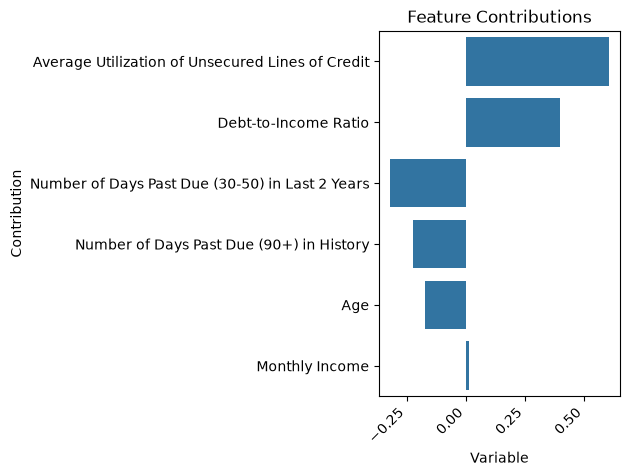

In [66]:
sns.barplot(
    data = var_contri_table,
    x = "contri",
    y = "variable_desc",
    order = var_contri_table["variable_desc"]
)

plt.xlabel("Variable")
plt.ylabel("Contribution")
plt.title("Feature Contributions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()